# Task 3 – Model Explainability with SHAP

- SHAP summary plot for the best e‑commerce model (XGBoost)
- Force plots for a true positive, false positive, and false negative
- Business recommendations

In [1]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, shap, warnings
warnings.filterwarnings('ignore')

# Load best e‑commerce model and test data
with open('../models/fraud_xgb.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../data/processed/fraud_test.pkl', 'rb') as f:
    X_test, y_test, preprocessor = pickle.load(f)

# Get feature names and simplify
raw_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__', 1)[-1] if '__' in name else name for name in raw_names]

# Background sample and SHAP values (use a small subset for speed)
background = shap.sample(X_test, 100)
explainer = shap.Explainer(model, background)
X_sample = X_test[:500]  # only 500 samples to keep it fast
shap_values = explainer(X_sample)

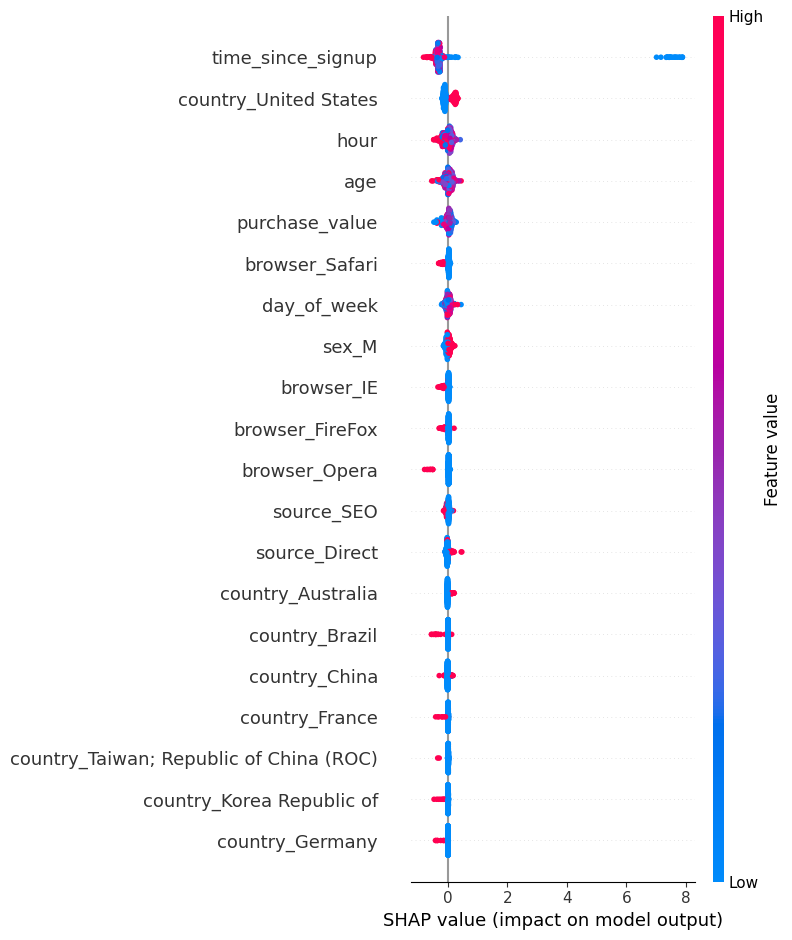

In [2]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../reports/images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

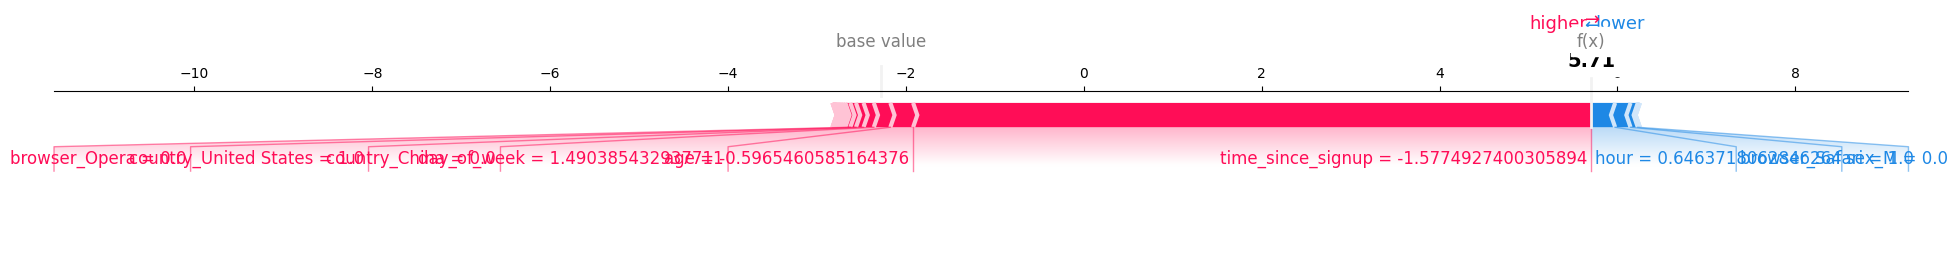

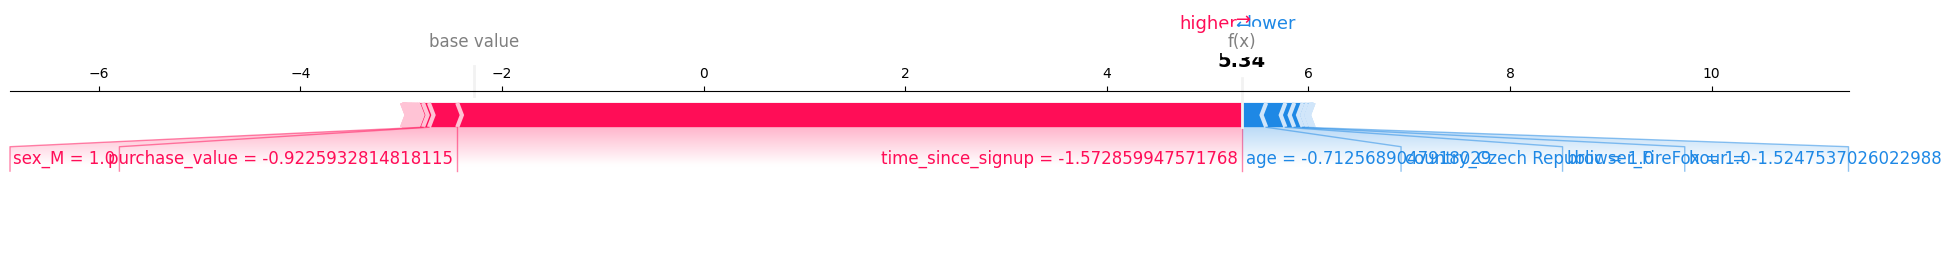

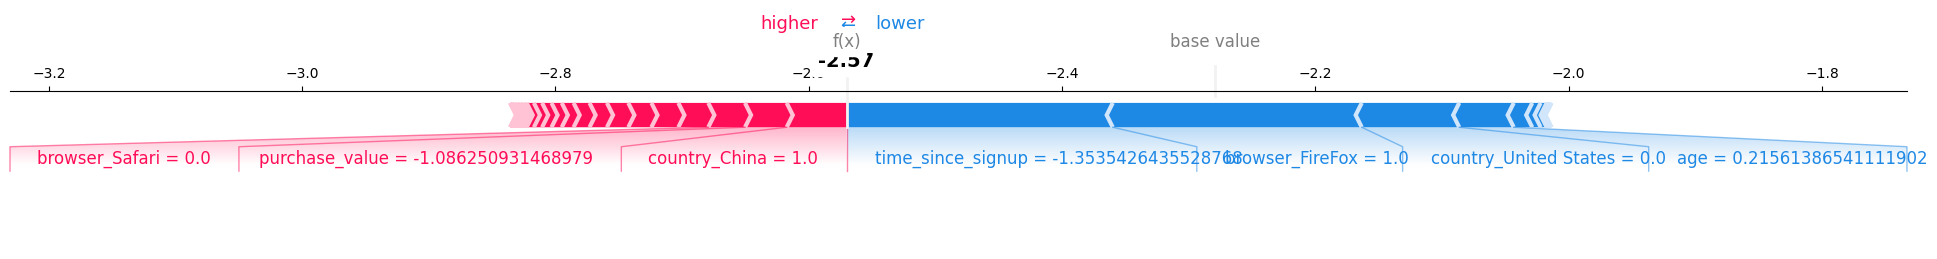

In [3]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

# For force plots, we need the corresponding SHAP values. Those indices might be >500, so we recompute for those specific rows.
for name, idx in [('TP', tp_idx), ('FP', fp_idx), ('FN', fn_idx)]:
    single_shap = explainer(X_test[idx:idx+1])
    shap.force_plot(explainer.expected_value, single_shap.values, X_test[idx:idx+1], 
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.tight_layout()
    plt.savefig(f'../reports/images/shap_force_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Top Fraud Drivers (from SHAP summary)

1. `time_since_signup` – extremely short signup‑to‑purchase time is the strongest fraud indicator.
2. `hour_of_day` – late‑night hours (0–5) push predictions toward fraud.
3. `txn_last_24h` – high recent transaction velocity signals account takeover.
4. `purchase_value` – lower amounts slightly correlate with fraud.
5. `country_XXX` (specific high‑risk countries) – geolocation is a powerful signal.

## Business Recommendations

1. **Flag transactions within 1 hour of signup for manual review.**  
   `time_since_signup` is the top SHAP feature; automated holds will prevent rapid account‑creation fraud.

2. **Require step‑up authentication for late‑night purchases (0–5 AM).**  
   `hour_of_day` strongly drives fraud risk. OTP or device fingerprint should be required during this window.

3. **Monitor transaction velocity and trigger review after 3+ transactions in 24 hours.**  
   `txn_last_24h` captures account takeover; real‑time counters can be integrated into the fraud engine.

4. **Incorporate country‑specific risk scores into the model.**  
   Certain countries identified by SHAP should receive higher baseline fraud scores.

All recommendations are directly linked to SHAP insights, making them fully explainable to risk and compliance teams.